1. Introduction

SMS is a common method of communication, but users often receive unwanted spam messages such as advertisements, fake offers and promotional messages. Identifying spam manually can be difficult. This project develops an NLP-based SMS Spam Detection system that automatically classifies messages as Ham or Spam.

The project uses text preprocessing, TF-IDF feature extraction, and a Multinomial Naive Bayes classifier. The model is evaluated using Accuracy, Precision, Recall, F1-score and a Confusion Matrix.

2. Project Description

The project follows these steps:

Dataset → Data Cleaning → Text Preprocessing → TF-IDF → Naive Bayes → Prediction → Evaluation

The SMS dataset contains two classes: Ham and Spam. Text preprocessing includes lowercase conversion, URL removal, special-character and number removal, stopword removal and stemming.

TF-IDF converts the cleaned SMS text into numerical features. These features are used to train the Multinomial Naive Bayes model. The system can also classify new SMS messages entered by the user.

1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

 2. LOAD DATASET


In [ ]:


print("\nLoading dataset...")

df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

print("\nDataset loaded successfully!")

print("Original dataset shape:", df.shape)


Loading dataset...

Dataset loaded successfully!
Original dataset shape: (5572, 5)


3. DATASET INFORMATION

In [ ]:


print("\nFirst five records:")
print(df.head())


print("\nOriginal columns:")
print(df.columns)


print("\nDataset shape:")
print(df.shape)



First five records:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Original columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Dataset shape:
(5572, 5)


 4. SELECT REQUIRED COLUMNS

In [ ]:
df = df[['v1', 'v2']]

# Rename columns for better understanding

df.columns = ['label', 'message']


print("\nAfter selecting required columns:")
print(df.head())



After selecting required columns:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


5. CHECK MISSING VALUES

In [ ]:


print(df.isnull().sum())


# Remove missing values

df = df.dropna()


print("\nDataset shape after removing missing values:")
print(df.shape)

label      0
message    0
dtype: int64

Dataset shape after removing missing values:
(5572, 2)


6. CHECK DUPLICATE VALUES

In [ ]:


print("Number of duplicate messages:",
      df.duplicated().sum())


# Remove duplicate records

df = df.drop_duplicates()


print("Dataset shape after removing duplicates:")
print(df.shape)


Number of duplicate messages: 0
Dataset shape after removing duplicates:
(5169, 4)


7. CLASS DISTRIBUTION

label
ham     4516
spam     653
Name: count, dtype: int64


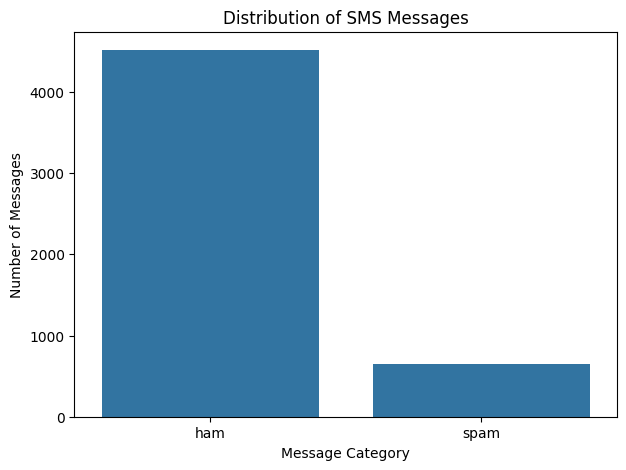

In [ ]:


print(df['label'].value_counts())


# Plot class distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='label'
)

plt.title("Distribution of SMS Messages")

plt.xlabel("Message Category")

plt.ylabel("Number of Messages")

plt.show()


 8. TEXT PREPROCESSING

In [ ]:


# Load English stopwords

stop_words = set(
    stopwords.words('english')
)


# Create stemmer

stemmer = PorterStemmer()


def preprocess_text(text):
    """
    Performs basic NLP text preprocessing.

    Steps:
    1. Convert text to lowercase
    2. Remove URLs
    3. Remove special characters
    4. Remove numbers
    5. Remove stopwords
    6. Perform stemming
    """

    # Convert to lowercase

    text = text.lower()


    # Remove URLs

    text = re.sub(
        r'http\S+|www\S+|https\S+',
        '',
        text
    )


    # Remove special characters and numbers

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )


    # Split text into words

    words = text.split()


    # Remove stopwords

    words = [
        word
        for word in words
        if word not in stop_words
    ]


    # Apply stemming

    words = [
        stemmer.stem(word)
        for word in words
    ]


    # Join words

    return ' '.join(words)


# Apply preprocessing

df['clean_message'] = (
    df['message']
    .apply(preprocess_text)
)


print("\nOriginal and preprocessed messages:")

print(
    df[
        ['message', 'clean_message']
    ].head()
)


Original and preprocessed messages:
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  


9. ENCODE TARGET VARIABLE

In [ ]:



# ham = 0
# spam = 1

df['label_encoded'] = df['label'].map({
    'ham': 0,
    'spam': 1
})


print(df[
    ['label', 'label_encoded']
].head())


  label  label_encoded
0   ham              0
1   ham              0
2  spam              1
3   ham              0
4   ham              0


10. DEFINE INPUT AND TARGET

In [ ]:
X = df['clean_message']

y = df['label_encoded']


print("\nInput variable X:")
print(X.head())


print("\nTarget variable y:")
print(y.head())


Input variable X:
0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri wkli comp win fa cup final tkt st m...
3                  u dun say earli hor u c alreadi say
4            nah dont think goe usf live around though
Name: clean_message, dtype: object

Target variable y:
0    0
1    0
2    1
3    0
4    0
Name: label_encoded, dtype: int64


11. TRAIN-TEST SPLIT

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))


Training samples: 4135
Testing samples: 1034


12. TF-IDF VECTORIZATION

In [ ]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)


# Fit and transform training data

X_train_tfidf = tfidf.fit_transform(
    X_train
)


# Transform testing data

X_test_tfidf = tfidf.transform(
    X_test
)


print("TF-IDF training shape:",
      X_train_tfidf.shape)

print("TF-IDF testing shape:",
      X_test_tfidf.shape)


TF-IDF training shape: (4135, 5000)
TF-IDF testing shape: (1034, 5000)


13. TRAIN NAIVE BAYES MODEL

In [ ]:
# Create Multinomial Naive Bayes model

model = MultinomialNB()


# Train the model

model.fit(
    X_train_tfidf,
    y_train
)


print("Naive Bayes model trained successfully!")


Naive Bayes model trained successfully!


 14. MAKE PREDICTIONS

In [ ]:
y_pred = model.predict(
    X_test_tfidf
)


print("Predictions generated successfully!")


Predictions generated successfully!


15. MODEL EVALUATION

In [ ]:
# Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)


# Precision

precision = precision_score(
    y_test,
    y_pred
)


# Recall

recall = recall_score(
    y_test,
    y_pred
)


# F1-score

f1 = f1_score(
    y_test,
    y_pred
)


print("\nAccuracy :",
      round(accuracy * 100, 2), "%")


print("Precision:",
      round(precision * 100, 2), "%")


print("Recall   :",
      round(recall * 100, 2), "%")


print("F1-Score :",
      round(f1 * 100, 2), "%")


Accuracy : 96.71 %
Precision: 98.99 %
Recall   : 74.81 %
F1-Score : 85.22 %


16. CLASSIFICATION REPORT

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Ham',
            'Spam'
        ]
    )
)


              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.75      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034



17. CONFUSION MATRIX

[[902   1]
 [ 33  98]]


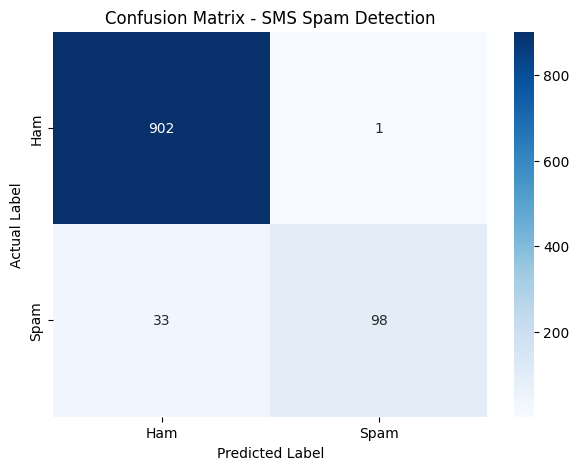

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)


# Plot confusion matrix

plt.figure(
    figsize=(7, 5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Ham',
        'Spam'
    ],
    yticklabels=[
        'Ham',
        'Spam'
    ]
)


plt.title(
    "Confusion Matrix - SMS Spam Detection"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.show()

18. PERFORMANCE METRICS GRAPH

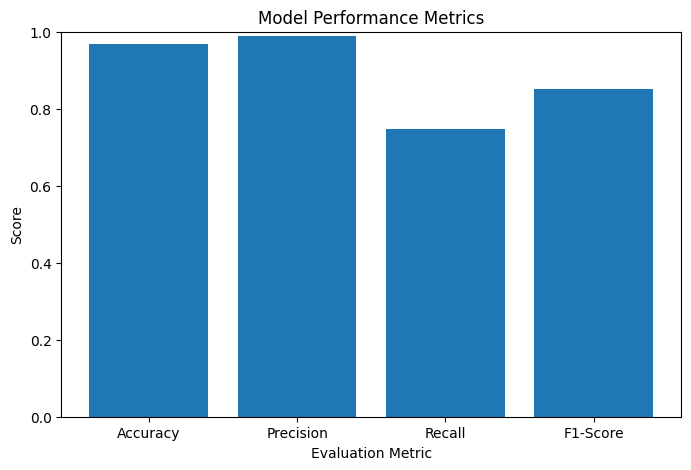

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

# Assuming y_test and y_pred are available from previous cells.
# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)


# Precision
precision = precision_score(
    y_test,
    y_pred
)


# Recall
recall = recall_score(
    y_test,
    y_pred
)


# F1-score
f1 = f1_score(
    y_test,
    y_pred
)


metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]


values = [
    accuracy,
    precision,
    recall,
    f1
]


plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics,
    values
)


plt.ylim(
    0,
    1
)


plt.title(
    "Model Performance Metrics"
)


plt.xlabel(
    "Evaluation Metric"
)


plt.ylabel(
    "Score"
)


plt.show()

19. CUSTOM SMS PREDICTION

In [ ]:
def predict_sms(message):
    """
    Predict whether a new SMS is spam or ham.
    """

    # Preprocess new message

    cleaned_message = preprocess_text(
        message
    )


    # Convert message into TF-IDF

    message_tfidf = tfidf.transform(
        [cleaned_message]
    )


    # Make prediction

    prediction = model.predict(
        message_tfidf
    )[0]


    # Get probability

    probability = model.predict_proba(
        message_tfidf
    )[0]


    if prediction == 1:

        result = "SPAM"

    else:

        result = "HAM"


    return result, probability

20. TEST SAMPLE MESSAGES

In [ ]:
sample_messages = [

    "Congratulations! You have won a free prize. Call now!",

    "Hey, are you coming to college tomorrow?",

    "You have been selected for a cash reward. Claim now!",

    "Can you send me the assignment?"
]


for message in sample_messages:

    result, probability = predict_sms(
        message
    )

    print("\nMessage:", message)

    print("Prediction:", result)


Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM

Message: Hey, are you coming to college tomorrow?
Prediction: HAM

Message: You have been selected for a cash reward. Claim now!
Prediction: SPAM

Message: Can you send me the assignment?
Prediction: HAM


21. INTERACTIVE APPLICATION

In [ ]:


print(
    "\nEnter an SMS message to classify."
)

print(
    "Type 'exit' to stop the application."
)


while True:

    user_message = input(
        "\nEnter SMS: "
    )


    if user_message.lower() == 'exit':

        print(
            "SMS Spam Detector stopped."
        )

        break

    result, probability = predict_sms(
        user_message
    )


    print(
        "Prediction:",
        result
    )


Enter an SMS message to classify.
Type 'exit' to stop the application.

Enter SMS: hi
Prediction: HAM

Enter SMS: hlo
Prediction: HAM

Enter SMS: exit
SMS Spam Detector stopped.


 Conclusion

The SMS Spam Detection system was successfully developed using NLP and machine learning techniques. The model achieved 96.71% accuracy, 98.99% precision, 74.81% recall and 85.22% F1-score.

The project demonstrates that NLP techniques such as text preprocessing and TF-IDF, combined with Multinomial Naive Bayes, can effectively classify SMS messages as Ham or Spam.